# 📣 Advertising Sales Predictor — Polynomial Regression
**Assignment 16 | Polynomial Regression Project**

Predicting product sales from TV, Radio, and Newspaper advertising budgets using polynomial features to capture **diminishing returns** at higher spending levels.

> *Dataset: 200 observations · 3 features · 1 target (Sales)*

---
### Library Import

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')

print('✅ Libraries ready')

✅ Libraries ready


---
### Data Import & First Look

In [3]:
df = pd.read_csv('advertising.csv')

print(f'Shape: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'Missing values: {df.isnull().sum().sum()}')
df.head()

Shape: 200 rows × 4 columns
Missing values: 0


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [4]:
df.describe().round(2)

,TV,Radio,Newspaper,Sales
count,200.00,200.00,200.00,200.00
mean,147.04,23.26,30.55,15.13
std,85.85,14.85,21.78,5.28
min,0.70,0.00,0.30,1.60
25%,74.38,9.98,12.75,11.00
50%,149.75,22.90,25.75,16.00
75%,218.82,36.52,45.10,19.05
max,296.40,49.60,114.00,27.00


---
### Exploratory Data Analysis

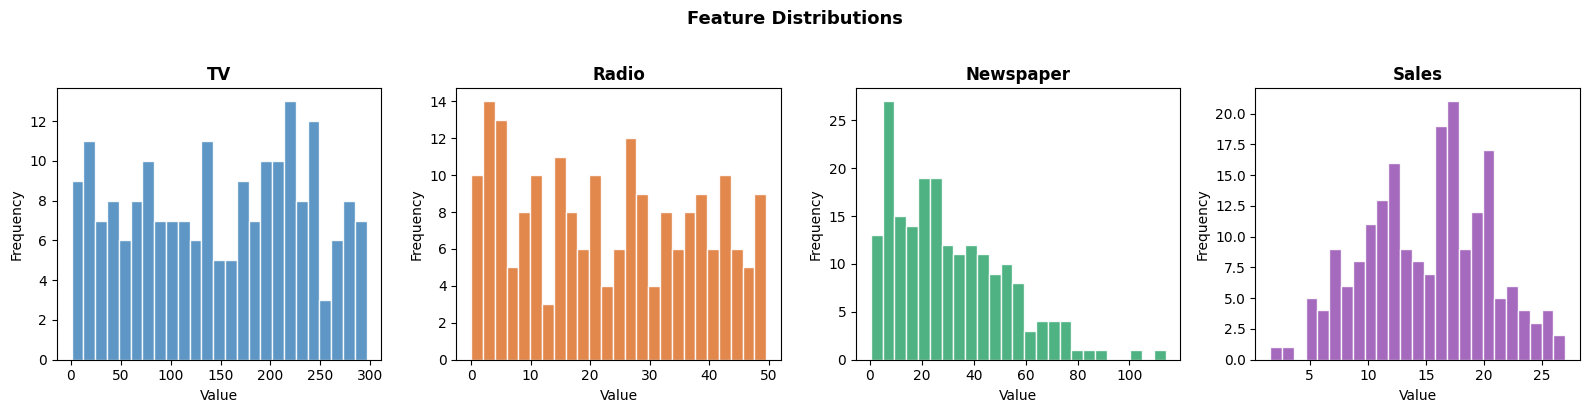

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
cols  = ['TV', 'Radio', 'Newspaper', 'Sales']
colors = ['#4C8CBF', '#E07B3A', '#3BAA74', '#9B59B6']

for ax, col, c in zip(axes, cols, colors):
    ax.hist(df[col], bins=25, color=c, edgecolor='white', alpha=0.9)
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

plt.suptitle('Feature Distributions', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

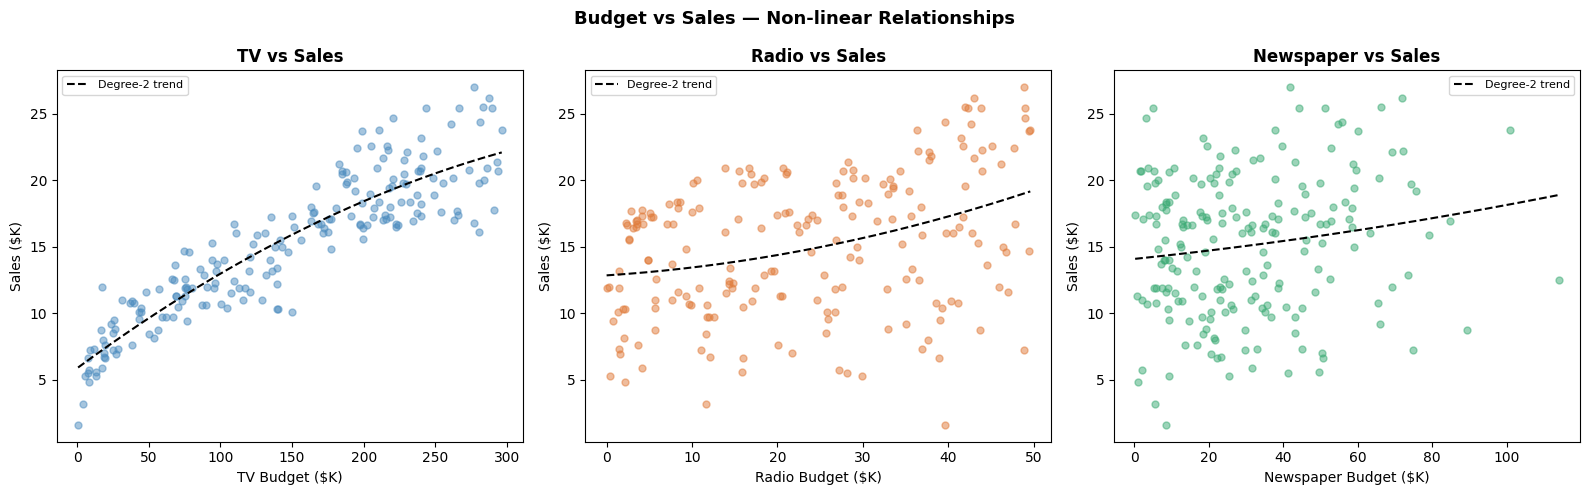

💡 Note: TV and Radio show clear curves — diminishing returns at higher spend.


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
channels = ['TV', 'Radio', 'Newspaper']
colors   = ['#4C8CBF', '#E07B3A', '#3BAA74']

for ax, ch, c in zip(axes, channels, colors):
    ax.scatter(df[ch], df['Sales'], alpha=0.5, s=25, color=c)
    # Polynomial trend overlay (degree 2)
    z = np.polyfit(df[ch], df['Sales'], 2)
    p = np.poly1d(z)
    x_range = np.linspace(df[ch].min(), df[ch].max(), 200)
    ax.plot(x_range, p(x_range), 'k--', linewidth=1.5, label='Degree-2 trend')
    ax.set_xlabel(f'{ch} Budget ($K)')
    ax.set_ylabel('Sales ($K)')
    ax.set_title(f'{ch} vs Sales', fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Budget vs Sales — Non-linear Relationships', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('💡 Note: TV and Radio show clear curves — diminishing returns at higher spend.')

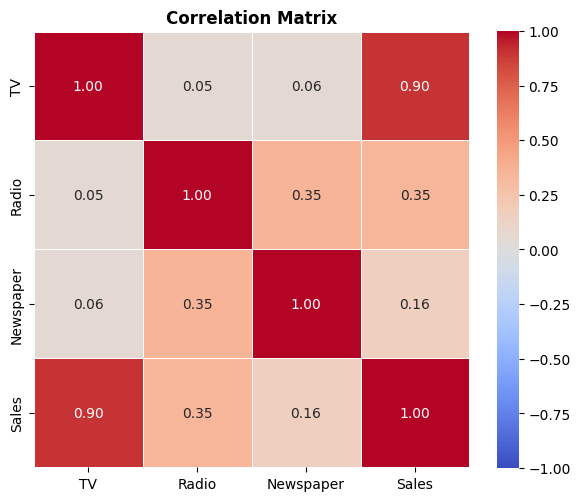

In [7]:
plt.figure(figsize=(6, 5))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1, square=True)
plt.title('Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

---
### Feature Engineering — Polynomial Transformation

> We use `PolynomialFeatures` to generate new inputs from the original three: **TV², Radio², Newspaper², TV×Radio, TV×Newspaper, Radio×Newspaper**, plus the originals — giving the model the power to learn curves and interactions.

In [8]:
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

# Show what degree-2 transformation creates
poly_demo = PolynomialFeatures(degree=2, include_bias=False)
X_poly_demo = poly_demo.fit_transform(X)

feature_names = poly_demo.get_feature_names_out(['TV', 'Radio', 'Newspaper'])
print(f'Original features  : {X.shape[1]}')
print(f'After degree-2 poly: {X_poly_demo.shape[1]}')
print(f'\nNew feature names  : {list(feature_names)}')

Original features  : 3
After degree-2 poly: 9

New feature names  : ['TV', 'Radio', 'Newspaper', 'TV^2', 'TV Radio', 'TV Newspaper', 'Radio^2', 'Radio Newspaper', 'Newspaper^2']


---
### Train / Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training samples : {X_train.shape[0]}')
print(f'Test samples     : {X_test.shape[0]}')

Training samples : 160
Test samples     : 40


---
### Degree Comparison — Finding the Sweet Spot

In [11]:
results = {}

for deg in [1, 2, 3]:
    pipe = Pipeline([
        ('poly',  PolynomialFeatures(degree=deg, include_bias=False)),
        ('model', LinearRegression())
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    cv_r2  = cross_val_score(pipe, X, y, cv=5, scoring='r2').mean()

    results[deg] = {
        'R²':      round(r2_score(y_test, y_pred), 4),
        'MAE':     round(mean_absolute_error(y_test, y_pred), 4),
        'RMSE':    round(np.sqrt(mean_squared_error(y_test, y_pred)), 4),
        'CV R²':   round(cv_r2, 4),
        'Features':PolynomialFeatures(degree=deg).fit(X).n_output_features_
    }

results_df = pd.DataFrame(results).T
results_df.index.name = 'Degree'
print('Degree comparison:')
results_df

Degree comparison:


,R²,MAE,RMSE,CV R²,Features
Degree,,,,,
1,0.9059,1.2748,1.7052,0.8954,4.0
2,0.9533,0.9034,1.2011,0.9254,10.0
3,0.9414,0.9347,1.3462,0.9170,20.0


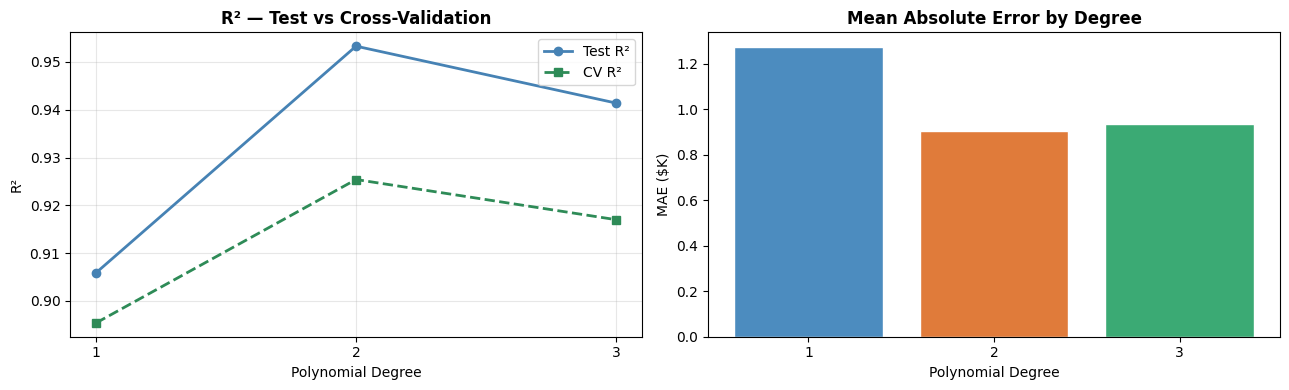

✅ Degree 2 wins: best R² and lowest MAE without overfitting.


In [12]:
degrees = list(results.keys())
r2_vals  = [results[d]['R²']   for d in degrees]
cv_vals  = [results[d]['CV R²'] for d in degrees]
mae_vals = [results[d]['MAE']  for d in degrees]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(degrees, r2_vals,  'o-', label='Test R²',  color='steelblue', linewidth=2)
axes[0].plot(degrees, cv_vals,  's--', label='CV R²',   color='seagreen',  linewidth=2)
axes[0].set_xticks(degrees)
axes[0].set_xlabel('Polynomial Degree')
axes[0].set_ylabel('R²')
axes[0].set_title('R² — Test vs Cross-Validation', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].bar([str(d) for d in degrees], mae_vals,
            color=['#4C8CBF','#E07B3A','#3BAA74'], edgecolor='white')
axes[1].set_xlabel('Polynomial Degree')
axes[1].set_ylabel('MAE ($K)')
axes[1].set_title('Mean Absolute Error by Degree', fontweight='bold')

plt.tight_layout()
plt.show()
print('✅ Degree 2 wins: best R² and lowest MAE without overfitting.')

---
### Train the Final Model (Degree 2)

In [13]:
# Build the final pipeline with degree 2
model = Pipeline([
    ('poly',  PolynomialFeatures(degree=2, include_bias=False)),
    ('reg',   LinearRegression())
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print('═' * 42)
print('      FINAL MODEL — DEGREE 2 POLYNOMIAL')
print('═' * 42)
print(f'  R²    : {r2:.4f}   ({r2*100:.1f}% variance explained)')
print(f'  MAE   : ${mae:.4f}K')
print(f'  RMSE  : ${rmse:.4f}K')
print('═' * 42)

══════════════════════════════════════════
      FINAL MODEL — DEGREE 2 POLYNOMIAL
══════════════════════════════════════════
  R²    : 0.9533   (95.3% variance explained)
  MAE   : $0.9034K
  RMSE  : $1.2011K
══════════════════════════════════════════


---
### Prediction & Evaluation

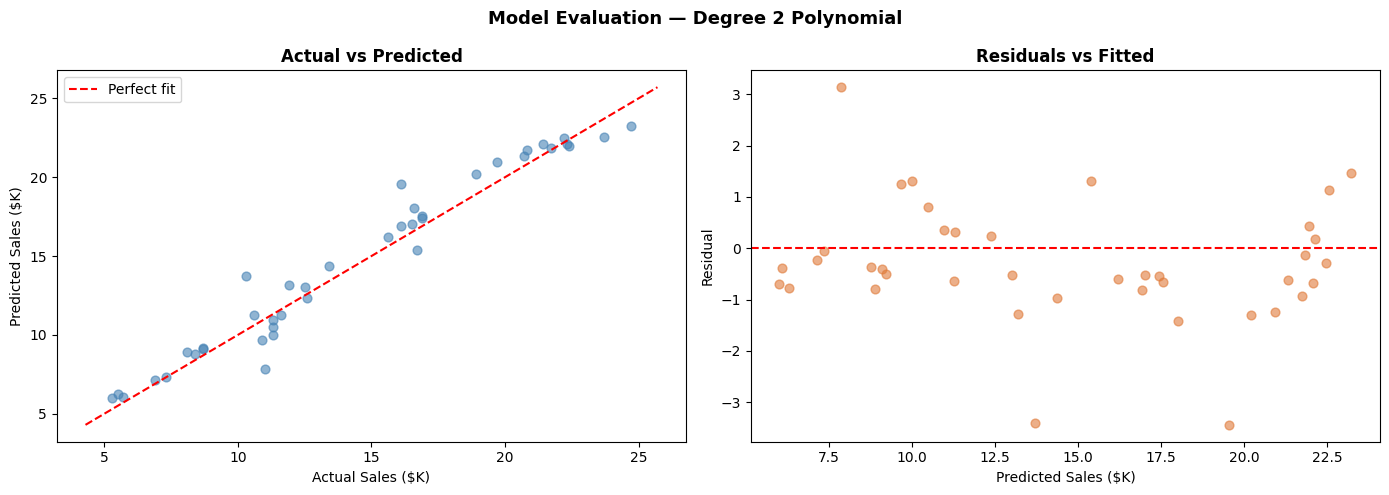

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.6, color='steelblue', s=40)
lims = [min(y_test.min(), y_pred.min()) - 1,
        max(y_test.max(), y_pred.max()) + 1]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect fit')
axes[0].set_xlabel('Actual Sales ($K)')
axes[0].set_ylabel('Predicted Sales ($K)')
axes[0].set_title('Actual vs Predicted', fontweight='bold')
axes[0].legend()

# Residuals
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.6, color='#E07B3A', s=40)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Predicted Sales ($K)')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residuals vs Fitted', fontweight='bold')

plt.suptitle('Model Evaluation — Degree 2 Polynomial', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

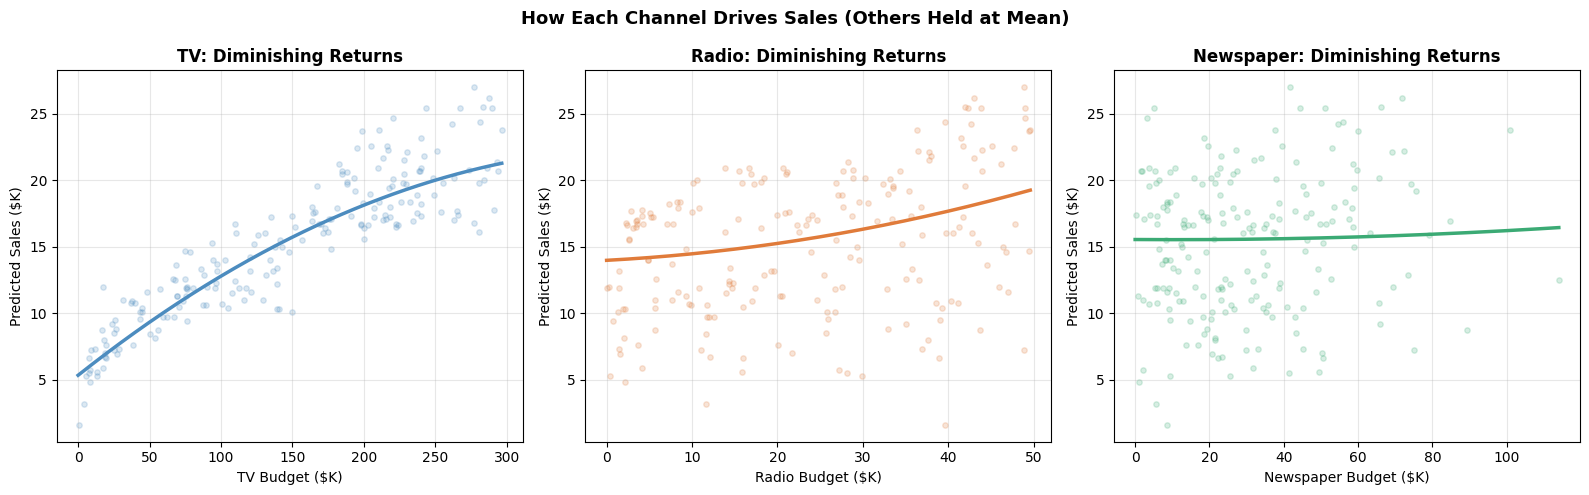

In [15]:
# Diminishing returns curves — vary each channel while holding others at mean
tv_mean   = df['TV'].mean()
rad_mean  = df['Radio'].mean()
news_mean = df['Newspaper'].mean()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
channels  = ['TV', 'Radio', 'Newspaper']
colors    = ['#4C8CBF', '#E07B3A', '#3BAA74']
means     = [tv_mean, rad_mean, news_mean]

for ax, ch, c, other_means in zip(axes, channels, colors,
        [(rad_mean, news_mean), (tv_mean, news_mean), (tv_mean, rad_mean)]):
    x_range = np.linspace(0, df[ch].max(), 300)
    if ch == 'TV':
        X_sim = pd.DataFrame({'TV': x_range, 'Radio': other_means[0], 'Newspaper': other_means[1]})
    elif ch == 'Radio':
        X_sim = pd.DataFrame({'TV': other_means[0], 'Radio': x_range, 'Newspaper': other_means[1]})
    else:
        X_sim = pd.DataFrame({'TV': other_means[0], 'Radio': other_means[1], 'Newspaper': x_range})

    y_sim = model.predict(X_sim)

    ax.plot(x_range, y_sim, color=c, linewidth=2.5)
    ax.scatter(df[ch], df['Sales'], alpha=0.2, s=15, color=c)
    ax.set_xlabel(f'{ch} Budget ($K)')
    ax.set_ylabel('Predicted Sales ($K)')
    ax.set_title(f'{ch}: Diminishing Returns', fontweight='bold')
    ax.grid(alpha=0.3)

plt.suptitle('How Each Channel Drives Sales (Others Held at Mean)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
### Coefficient Analysis

In [16]:
poly_step  = model.named_steps['poly']
reg_step   = model.named_steps['reg']
feat_names = poly_step.get_feature_names_out(['TV', 'Radio', 'Newspaper'])

coef_df = pd.DataFrame({
    'Feature'    : feat_names,
    'Coefficient': reg_step.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print(f'Intercept: {reg_step.intercept_:.4f}\n')
coef_df

Intercept: 5.1509



,Feature,Coefficient
0,TV,0.076216
1,Radio,-0.031984
2,Newspaper,-0.001920
6,Radio^2,0.001448
4,TV Radio,0.000419
7,Radio Newspaper,0.000165
3,TV^2,-0.000106
8,Newspaper^2,0.000085
5,TV Newspaper,-0.000026


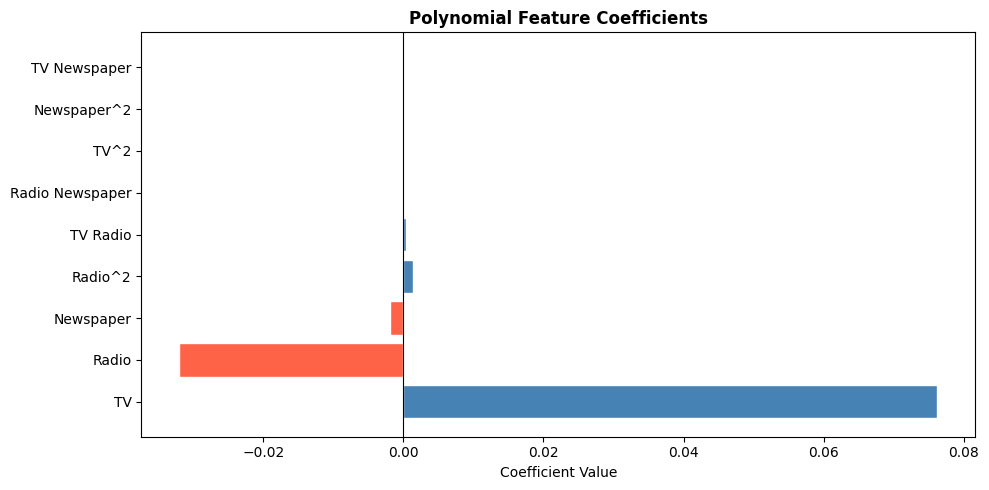

In [17]:
plt.figure(figsize=(10, 5))
colors = ['steelblue' if c >= 0 else 'tomato' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coefficient Value')
plt.title('Polynomial Feature Coefficients', fontweight='bold')
plt.tight_layout()
plt.show()

---
### Custom Prediction

In [18]:
# 🔮 Change these values to predict for any budget combination
tv_budget        = 150.0   # $K
radio_budget     =  30.0   # $K
newspaper_budget =  20.0   # $K

sample = pd.DataFrame([[tv_budget, radio_budget, newspaper_budget]],
                      columns=['TV', 'Radio', 'Newspaper'])
predicted_sales = model.predict(sample)[0]

print('Budget Input:')
print(f'  TV        : ${tv_budget:.1f}K')
print(f'  Radio     : ${radio_budget:.1f}K')
print(f'  Newspaper : ${newspaper_budget:.1f}K')
print(f'  Total     : ${tv_budget + radio_budget + newspaper_budget:.1f}K')
print()
print(f'💰 Predicted Sales: ${predicted_sales:.2f}K')

Budget Input:
  TV        : $150.0K
  Radio     : $30.0K
  Newspaper : $20.0K
  Total     : $200.0K

💰 Predicted Sales: $16.45K


## Concluding Analysis

- **Best model:** Polynomial Degree 2 — R² **0.9533**, MAE **$0.90K**, RMSE **$1.20K**
- **vs Linear (Degree 1):** R² was 0.9059 — polynomial closed that gap by adding squared + interaction terms
- **Degree 3 overfit:** R² dropped back to 0.9414 on test, CV R² fell from 0.925 → 0.917 — more parameters hurt, not helped

- **TV** is the primary driver (coef: +0.076) but hits diminishing returns past ~$200K (TV² = −0.000106)
- **Radio** accelerates at higher spend (Radio² = +0.001448) and synergises with TV (TV×Radio = +0.000419)
- **Newspaper** is near-useless — raw correlation with sales is only 0.16, model coefficient collapses to −0.002

- **Budget insight:** reallocating newspaper spend to TV or Radio will almost always improve returns
- **Sample prediction:** TV $150K + Radio $30K + Newspaper $20K → **$16.45K in sales**
- **Key takeaway:** the curve, not the line, is what makes this model work — and degree 2 is the sweet spot